In [1]:
# Libraries we are using here
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
# RFM & CLV
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter
from lifetimes.plotting import plot_period_transactions
# Sklearn
from sklearn.preprocessing import MinMaxScaler
import warnings 
warnings.filterwarnings("ignore")
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", lambda x: '%.3f' % x)


In [2]:
import mysql.connector
import pandas as pd

In [3]:
#  MySQL connector
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="anubrata",
    database="online_retail_db"
)

In [4]:
# Load dataset
query = "SELECT * FROM clean_transactions"
df = pd.read_sql(query, conn)

In [5]:
# Alternate way to Load Dataset
# df = pd.read_csv("cleaned_data.csv")

In [6]:
# First view to the dataset (to see 1st 5 rows )
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2024-01-12 08:26:00,2.550,17850,United Kingdom\r
1,536365,71053,WHITE METAL LANTERN,6,2024-01-12 08:26:00,3.390,17850,United Kingdom\r
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2024-01-12 08:26:00,2.750,17850,United Kingdom\r
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2024-01-12 08:26:00,3.390,17850,United Kingdom\r
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2024-01-12 08:26:00,3.390,17850,United Kingdom\r


In [7]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2024-01-12 08:26:00,2.550,17850,United Kingdom\r
1,536365,71053,WHITE METAL LANTERN,6,2024-01-12 08:26:00,3.390,17850,United Kingdom\r
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2024-01-12 08:26:00,2.750,17850,United Kingdom\r
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2024-01-12 08:26:00,3.390,17850,United Kingdom\r
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2024-01-12 08:26:00,3.390,17850,United Kingdom\r
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2024-01-12 08:26:00,7.650,17850,United Kingdom\r
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2024-01-12 08:26:00,4.250,17850,United Kingdom\r
7,536366,22633,HAND WARMER UNION JACK,6,2024-01-12 08:28:00,1.850,17850,United Kingdom\r
8,536366,22632,HAND WARMER RED POLKA DOT,6,2024-01-12 08:28:00,1.850,17850,United Kingdom\r
9,536368,22960,JAM MAKING SET WITH JARS,6,2024-01-12 08:34:00,4.250,13047,United Kingdom\r


In [8]:
#for last 5 rows
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
392684,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2025-09-12 12:50:00,2.100,12680,France\r
392685,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2025-09-12 12:50:00,4.150,12680,France\r
392686,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2025-09-12 12:50:00,4.150,12680,France\r
392687,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2025-09-12 12:50:00,4.950,12680,France\r
392688,581587,26734,POSTAGE,1,2025-09-12 12:50:00,18.000,12680,France\r


In [9]:
# to see total no.s of columns and rows
df.shape

(392689, 8)

In [10]:
len(df)

392689

In [11]:
#---------------------  Data Preprocessing  ----------------------

In [12]:

def check_df(dataframe):
    print("------------------- Shape ------------------------")
    print(dataframe.shape)
    print("------------------- Columns ----------------------")
    print(dataframe.columns)
    print("------------------- Types ------------------------")
    print(dataframe.dtypes)
    print("------------------- Head -------------------------")
    print(dataframe.head())
    print("------------------- Tail -------------------------")
    print(dataframe.tail())
    print("------------------- Describe ---------------------")
    print(dataframe.describe().T)

check_df(df)

------------------- Shape ------------------------
(392689, 8)
------------------- Columns ----------------------
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'CustomerID', 'Country'],
      dtype='object')
------------------- Types ------------------------
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
CustomerID             object
Country                object
dtype: object
------------------- Head -------------------------
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392689 entries, 0 to 392688
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      392689 non-null  object        
 1   StockCode    392689 non-null  object        
 2   Description  392689 non-null  object        
 3   Quantity     392689 non-null  int64         
 4   InvoiceDate  392689 non-null  datetime64[ns]
 5   Price        392689 non-null  float64       
 6   CustomerID   392689 non-null  object        
 7   Country      392689 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 24.0+ MB


In [14]:

df = df.dropna(subset=['InvoiceDate'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392689 entries, 0 to 392688
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      392689 non-null  object        
 1   StockCode    392689 non-null  object        
 2   Description  392689 non-null  object        
 3   Quantity     392689 non-null  int64         
 4   InvoiceDate  392689 non-null  datetime64[ns]
 5   Price        392689 non-null  float64       
 6   CustomerID   392689 non-null  int64         
 7   Country      392689 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 24.0+ MB


In [16]:
#check missing (null) values
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
CustomerID     0
Country        0
dtype: int64

In [17]:
# optional: drop invalid rows
df.dropna(inplace=True)
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
CustomerID     0
Country        0
dtype: int64

In [18]:
# Total number of product in the dataset.
print("the sum of product in the dataset:", df["Description"].count())

the sum of product in the dataset: 392689


In [19]:
# Total revenue in the dataset
total_price_of_df = ((df["Quantity"] * df["Price"]).sum()).astype(float)
print("The sum of price in the dataset:", total_price_of_df)

The sum of price in the dataset: 8887226.889999999


In [20]:
# Dataset ordered from highest price to lowest price
df.sort_values(by = "Price", ascending  = False).head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
116867,551697,POST,POSTAGE,1,2025-03-05 13:46:00,8142.750,16029,United Kingdom\r
305360,573077,M,Manual,1,2025-10-27 14:13:00,4161.060,12536,France\r
305361,573080,M,Manual,1,2025-10-27 14:20:00,4161.060,12536,France\r
292016,571751,M,Manual,1,2025-10-19 11:18:00,3949.320,12744,Singapore\r
266722,569382,M,Manual,1,2025-03-10 16:44:00,3155.950,15502,United Kingdom\r


In [21]:
# Dataset ordered from lowest price to highest price
df.sort_values(by = "Price", ascending  = True).head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
163422,557639,16045,POPART WOODEN PENCILS ASST,100,2025-06-21 16:13:00,0.040,12933,United Kingdom\r
293015,571904,16045,POPART WOODEN PENCILS ASST,100,2025-10-19 14:41:00,0.040,12522,Germany\r
295207,572092,16045,POPART WOODEN PENCILS ASST,100,2025-10-20 14:41:00,0.040,17125,United Kingdom\r
162390,557492,16045,POPART WOODEN PENCILS ASST,100,2025-06-20 15:08:00,0.040,13717,United Kingdom\r
289238,571496,16045,POPART WOODEN PENCILS ASST,100,2025-10-17 15:02:00,0.040,13265,United Kingdom\r


In [22]:
#Outlier Observations :Define a safe range for values

In [23]:
def outlier_thresholds(dataframe, variable):
    quartile1 = dataframe[variable].quantile(0.01)
    quartile3 = dataframe[variable].quantile(0.99)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

replace_with_thresholds(df, "Quantity")  #Fix outliers in Quantity
replace_with_thresholds(df, "Price")     #Fix outliers in Price column

In [24]:
# ----------------------------- Exploratory Data Analysis --------------------------

In [25]:
#Categorical Variables

cat_cols = [col for col in df.columns if df[col].dtypes =="O"]
cat_but_car = [col for col in df.columns if df[col].nunique() > 100 and df[col].dtypes == "O"]
cat_cols = [col for col in cat_cols if col not in cat_but_car]
cat_cols

['Country']

                        Country  Ratio
Country                               
United Kingdom\r         349199 88.925
Germany\r                  9025  2.298
France\r                   8327  2.121
EIRE\r                     7226  1.840
Spain\r                    2479  0.631
Netherlands\r              2359  0.601
Belgium\r                  2031  0.517
Switzerland\r              1841  0.469
Portugal\r                 1453  0.370
Australia\r                1181  0.301
Norway\r                   1071  0.273
Italy\r                     758  0.193
Channel Islands\r           747  0.190
Finland\r                   685  0.174
Cyprus\r                    603  0.154
Sweden\r                    450  0.115
Austria\r                   398  0.101
Denmark\r                   380  0.097
Poland\r                    330  0.084
Japan\r                     321  0.082
Israel\r                    245  0.062
Unspecified\r               241  0.061
Singapore\r                 222  0.057
Iceland\r                

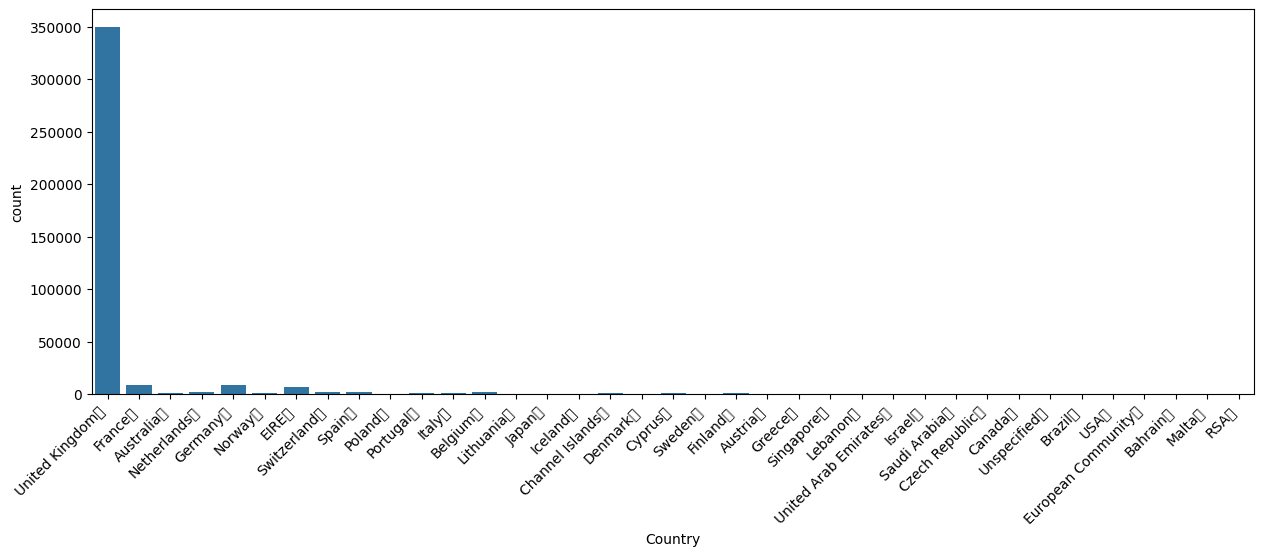

In [26]:
def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("-------------------------------------")
    if plot:
        fig_dims = (15, 5)
        fig, ax = plt.subplots(figsize=fig_dims)
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.xticks(rotation = 45, ha = 'right')
        plt.show()

cat_summary(df, "Country", plot=True)

In [27]:
#Numerical Variables

num_cols = [col for col in df.columns if df[col].dtypes != 'O' and col not in ["CustomerID" , "Invoice"]]
print(num_cols)

['Quantity', 'InvoiceDate', 'Price']


count   392689.000
mean        11.950
std         25.654
min          1.000
5%           1.000
10%          1.000
20%          2.000
30%          2.000
40%          4.000
50%          6.000
60%          8.000
70%         12.000
80%         12.000
90%         24.000
95%         36.000
99%        120.000
max        298.500
Name: Quantity, dtype: float64


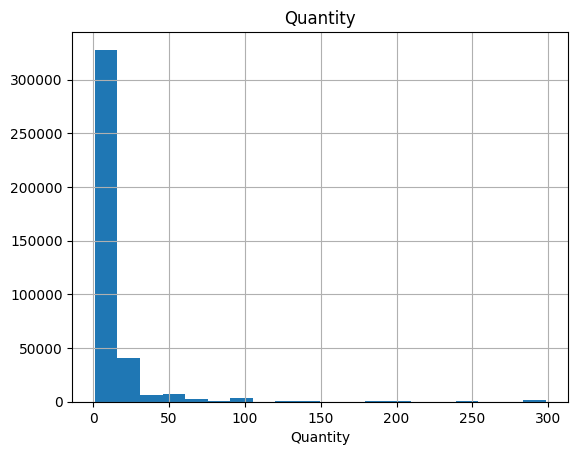

count                           392689
mean     2025-06-21 08:17:08.748908800
min                2024-01-12 08:26:00
5%                 2024-12-14 15:43:00
10%                2025-01-16 16:23:00
20%                2025-03-08 13:39:00
30%                2025-04-15 14:21:00
40%                2025-06-01 13:00:00
50%                2025-07-09 08:18:00
60%                2025-08-15 14:32:00
70%                2025-09-22 18:07:00
80%                2025-10-21 14:41:00
90%                2025-11-16 17:10:00
95%                2025-11-25 12:20:00
99%                2025-12-07 14:17:00
max                2025-12-10 17:19:00
Name: InvoiceDate, dtype: object


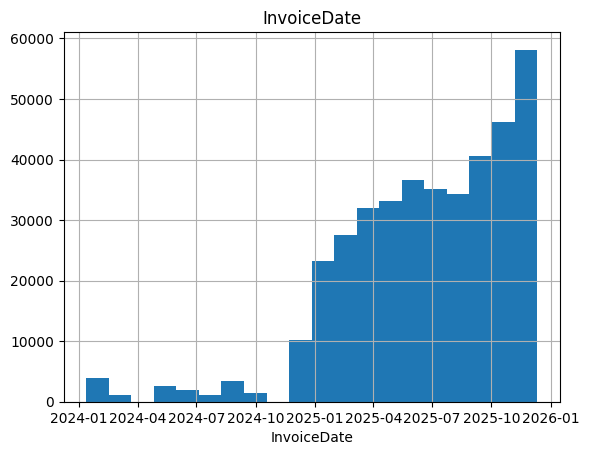

count   392689.000
mean         2.900
std          3.238
min          0.040
5%           0.420
10%          0.550
20%          0.850
30%          1.250
40%          1.650
50%          1.950
60%          2.100
70%          2.950
80%          4.150
90%          6.350
95%          8.500
99%         14.950
max         37.060
Name: Price, dtype: float64


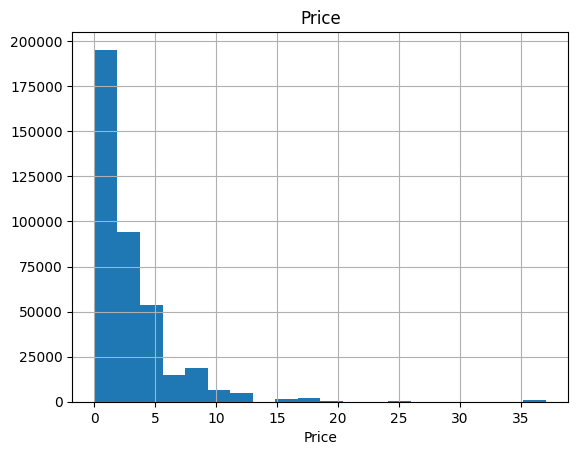

In [28]:
def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show()

for col in num_cols:
    num_summary(df, col, plot=True)

In [29]:
# unique product
df["StockCode"].nunique()

3665

In [30]:
# How many sales for each product?
df_product = df.groupby("Description").agg({"Quantity":"count"})
df_product.reset_index(inplace=True)
df_product

,Description,Quantity
0,10 COLOUR SPACEBOY PEN,243
1,12 COLOURED PARTY BALLOONS,142
2,12 DAISY PEGS IN WOOD BOX,66
3,12 EGG HOUSE PAINTED WOOD,64
4,12 HANGING EGGS HAND PAINTED,8
5,12 IVORY ROSE PEG PLACE SETTINGS,92
6,12 MESSAGE CARDS WITH ENVELOPES,194
7,12 PENCIL SMALL TUBE WOODLAND,286
8,12 PENCILS SMALL TUBE RED RETROSPOT,311
9,12 PENCILS SMALL TUBE SKULL,299


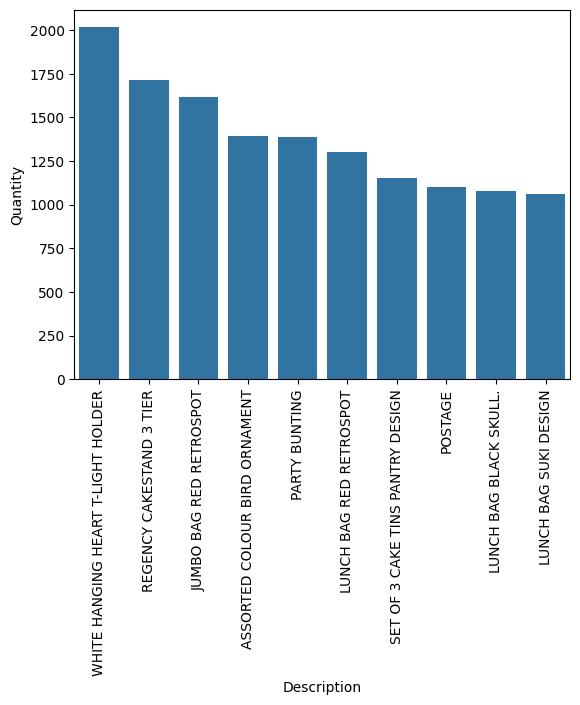

In [31]:
# Top 10 Products by quantity
top_pr= df_product.sort_values(by="Quantity",ascending=False).head(10)

sns.barplot(x="Description", y="Quantity", data=top_pr)
plt.xticks(rotation=90)
plt.show()

In [32]:
# Calculating total price per invoice and adding it.
df["TotalPrice"] = df["Price"] * df["Quantity"]

In [33]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.000,2024-01-12 08:26:00,2.550,17850,United Kingdom\r,15.300
1,536365,71053,WHITE METAL LANTERN,6.000,2024-01-12 08:26:00,3.390,17850,United Kingdom\r,20.340
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.000,2024-01-12 08:26:00,2.750,17850,United Kingdom\r,22.000
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.000,2024-01-12 08:26:00,3.390,17850,United Kingdom\r,20.340
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.000,2024-01-12 08:26:00,3.390,17850,United Kingdom\r,20.340


In [34]:
#  Strip carriage-return from Country  ─
df['Country'] = df['Country'].str.strip()          

# Compute TotalAmount ──
df['TotalAmount'] = df['Quantity'] * df['Price']

# ──  Summary Metrics ───────────────────────────────────────
total_revenue   = df['TotalAmount'].sum()
total_orders    = df['Invoice'].nunique()
total_customers = df['CustomerID'].nunique()
total_products  = df['StockCode'].nunique()
avg_order_value = total_revenue / total_orders

print("=" * 55)
print("        CORE BUSINESS METRICS  –  Consumer360")
print("=" * 55)
print(f"  Total Revenue      : £{total_revenue:>13,.2f}")
print(f"  Total Orders       : {total_orders:>13,}")
print(f"  Unique Customers   : {total_customers:>13,}")
print(f"  Unique Products    : {total_products:>13,}")
print(f"  Avg Order Value    : £{avg_order_value:>13,.2f}")
print("=" * 55)

        CORE BUSINESS METRICS  –  Consumer360
  Total Revenue      : £ 8,184,316.82
  Total Orders       :        18,530
  Unique Customers   :         4,338
  Unique Products    :         3,665
  Avg Order Value    : £       441.68


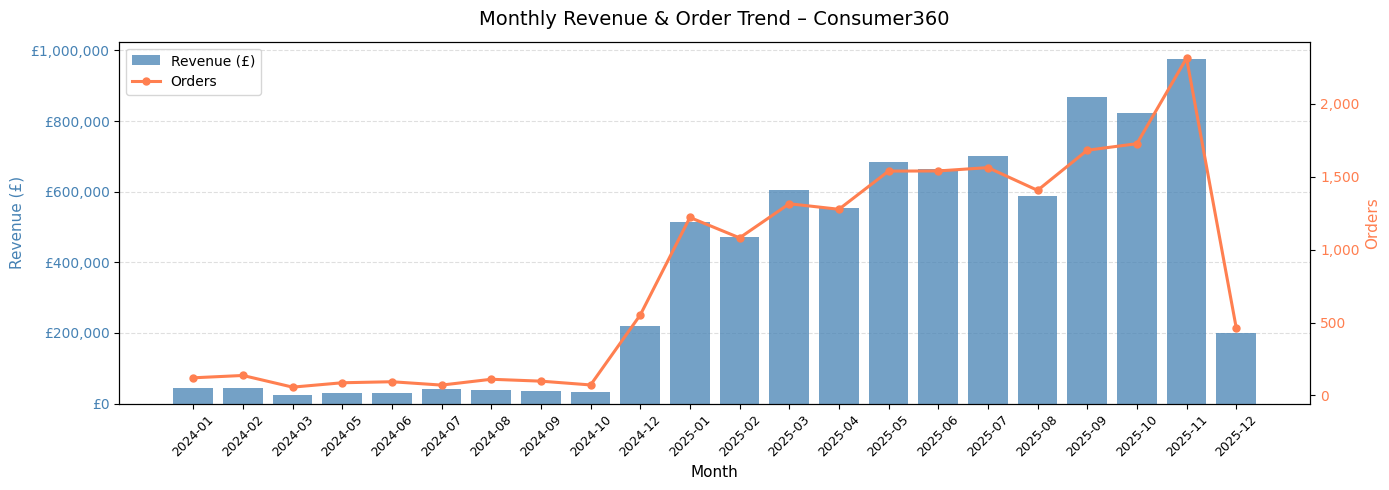

In [35]:

# ------------------- Monthly Sales Trend ----------------------

df['Month'] = df['InvoiceDate'].dt.to_period('M').astype(str)

monthly = (
    df.groupby('Month', sort=True)
      .agg(
          Revenue   = ('TotalAmount', 'sum'),
          Orders    = ('Invoice',     'nunique'),
          Customers = ('CustomerID',  'nunique')
      )
      .reset_index()
)

# Dual-axis bar + line chart
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

bars = ax1.bar(
    monthly['Month'], monthly['Revenue'],
    color='steelblue', alpha=0.75, label='Revenue (£)', zorder=2
)
line, = ax2.plot(
    monthly['Month'], monthly['Orders'],
    color='coral', marker='o', linewidth=2.2,
    markersize=5, label='Orders', zorder=3
)

ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Revenue (£)', color='steelblue', fontsize=11)
ax2.set_ylabel('Orders',      color='coral',     fontsize=11)
ax1.tick_params(axis='x', rotation=45, labelsize=9)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='coral')

# Format y-axis with £ and comma separator
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

ax1.set_title('Monthly Revenue & Order Trend – Consumer360', fontsize=14, pad=12)
ax1.grid(axis='y', linestyle='--', alpha=0.4, zorder=1)

# Combined legend
handles = [bars, line]
labels  = ['Revenue (£)', 'Orders']
ax1.legend(handles, labels, loc='upper left', fontsize=10)

plt.tight_layout()

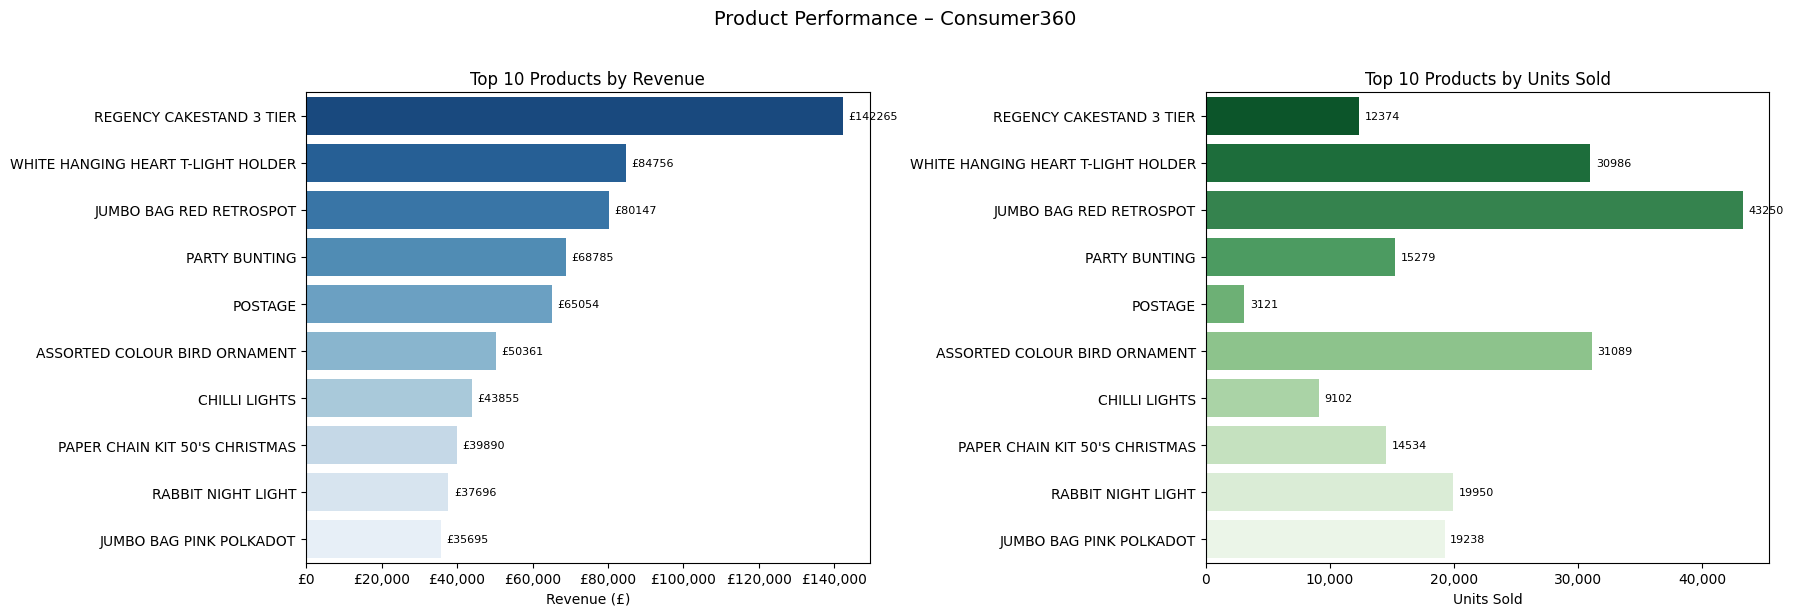

In [36]:

# ----------------- Top 10 Products by Revenue & Units -------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Top products calculation
top_products = (
    df.groupby('Description')
      .agg(
          Units=('Quantity', 'sum'),
          Revenue=('TotalAmount', 'sum')
      )
      .sort_values('Revenue', ascending=False)
      .head(10)
      .reset_index()
)

# Truncate long descriptions
top_products['Label'] = top_products['Description'].str[:40]

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ================= Revenue Chart =================
sns.barplot(
    data=top_products,
    y='Label',
    x='Revenue',
    palette='Blues_r',
    ax=axes[0]
)

axes[0].set_title('Top 10 Products by Revenue', fontsize=12)
axes[0].set_xlabel('Revenue (£)', fontsize=10)
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

# Fix for bar_label error
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='£%.0f', padding=4, fontsize=8)

# ================= Units Chart =================
sns.barplot(
    data=top_products,
    y='Label',
    x='Units',
    palette='Greens_r',
    ax=axes[1]
)

axes[1].set_title('Top 10 Products by Units Sold', fontsize=12)
axes[1].set_xlabel('Units Sold', fontsize=10)
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

# Fix for bar_label error
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f', padding=4, fontsize=8)

# Final layout
plt.suptitle('Product Performance – Consumer360', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [37]:

# -------------- Revenue by Country ------------------------

import plotly.express as px 

country_rev = (
    df.groupby('Country')
      .agg(
          Revenue   = ('TotalAmount', 'sum'),
          Orders    = ('Invoice',     'nunique'),
          Customers = ('CustomerID',  'nunique')
      )
      .sort_values('Revenue', ascending=False)
      .reset_index()
)

# Revenue % share
country_rev['Revenue_Pct'] = (
    country_rev['Revenue'] / country_rev['Revenue'].sum() * 100
).round(2)

print("\n── Revenue by Country (Top 10) ──────────────────────")
print(
    country_rev.head(10)
    .to_string(index=False,
               formatters={
                   'Revenue'     : '£{:,.2f}'.format,
                   'Revenue_Pct' : '{:.2f}%'.format
               })
)

# Plotly interactive bar
fig = px.bar(
    country_rev.head(20),
    x='Country',
    y='Revenue',
    color='Revenue',
    color_continuous_scale='Blues',
    text=country_rev.head(20)['Revenue_Pct'].apply(lambda x: f'{x:.1f}%'),
    title='Revenue by Country – Consumer360',
    labels={
        'Revenue': 'Total Revenue (£)',
        'Country': 'Country'
    },
    hover_data={
        'Orders': True,
        'Customers': True,
        'Revenue': ':,.2f'
    }
)

fig.update_traces(textposition='outside')

fig.update_layout(
    xaxis_tickangle=-40,
    coloraxis_showscale=False,
    title_font_size=15
)

fig.show()


── Revenue by Country (Top 10) ──────────────────────
       Country       Revenue  Orders  Customers Revenue_Pct
United Kingdom £6,656,948.34   16644       3920      81.34%
   Netherlands   £271,400.96      94          9       3.32%
          EIRE   £258,772.09     260          3       3.16%
       Germany   £225,534.03     457         94       2.76%
        France   £197,314.33     389         87       2.41%
     Australia   £133,682.51      57          9       1.63%
         Spain    £60,374.88      90         30       0.74%
   Switzerland    £56,149.95      51         21       0.69%
       Belgium    £41,193.45      98         25       0.50%
        Sweden    £35,335.21      36          8       0.43%


In [38]:

# -------------------------------- Quick Sales KPI Summary Table -------------------------- 

kpi_df = pd.DataFrame({
    'Metric'       : ['Total Revenue', 'Total Orders', 'Unique Customers',
                      'Unique Products', 'Avg Order Value',
                      'Date Range Start', 'Date Range End',
                      'Top Country'],
    'Value'        : [
        f'£{total_revenue:,.2f}',
        f'{total_orders:,}',
        f'{total_customers:,}',
        f'{total_products:,}',
        f'£{avg_order_value:,.2f}',
        str(df['InvoiceDate'].min().date()),
        str(df['InvoiceDate'].max().date()),
        country_rev.iloc[0]['Country']
    ]
})

print("\n── KPI Summary ──────────────────────────────────────")
print(kpi_df.to_string(index=False))
print("  Core metrics complete.")


── KPI Summary ──────────────────────────────────────
          Metric          Value
   Total Revenue  £8,184,316.82
    Total Orders         18,530
Unique Customers          4,338
 Unique Products          3,665
 Avg Order Value        £441.68
Date Range Start     2024-01-12
  Date Range End     2025-12-10
     Top Country United Kingdom
  Core metrics complete.


In [39]:
#---------------------------- Customer Segmentation With RFM --------------------------

'''The RFM model is based on three quantitative factors:
1. Recency: How recently a customer has made a purchase
2. Frequency: How often a customer makes a purchase
3. Monetary value: How much money a customer spends on purchases '''

'The RFM model is based on three quantitative factors:\n1. Recency: How recently a customer has made a purchase\n2. Frequency: How often a customer makes a purchase\n3. Monetary value: How much money a customer spends on purchases '

In [40]:
# Preparation of RFM Metrics
''' recency: the difference between today and the customer's last purchase date, in days
    frequency: customer's shopping frequency
    monetary: total money paid by the customer '''

" recency: the difference between today and the customer's last purchase date, in days\n    frequency: customer's shopping frequency\n    monetary: total money paid by the customer "

In [41]:
# Determining the analysis date for the recency
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [42]:
# The final date in the dataset is used as the reference date (‘today’) for recency calculations.
df["InvoiceDate"].max()

Timestamp('2025-12-10 17:19:00')

In [43]:
#This value is used to compute recency values.
today_date = dt.datetime(2025, 12, 11)

In [44]:
# Generating RFM metrics
rfm = df.groupby("CustomerID").agg({"InvoiceDate": lambda InvıiceDate: (today_date- InvıiceDate.max()).days, #Recency Calculation
                                    "Invoice": lambda Invoice: Invoice.nunique(),                             #Frequency Calculation
                                    "TotalPrice": lambda TotalPrice: TotalPrice.sum()})                       #Monetary Calculation

rfm.columns = ["recency","frequency","monetary"]
rfm.describe().T

,count,mean,std,min,25%,50%,75%,max
recency,4338.000,105.511,115.130,0.000,22.000,61.000,161.750,698.000
frequency,4338.000,4.272,7.698,1.000,1.000,2.000,5.000,209.000
monetary,4338.000,1886.657,7701.957,3.750,302.125,657.265,1625.530,266163.525


In [45]:
#Generating RFM Scores

In [46]:
# recency_score
rfm["recency_score"] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])
# frequency_score
rfm["frequency_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
# monetary_score
rfm["monetary_score"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5])

#  RFM Score
rfm["RFM_SCORE"] = (rfm["recency_score"].astype(str) + rfm["frequency_score"].astype(str))
rfm.head(10)

,recency,frequency,monetary,recency_score,frequency_score,monetary_score,RFM_SCORE
CustomerID,,,,,,,
12346,326,1,310.440,1,1,2,11
12347,40,7,4310.000,4,5,5,45
12348,76,4,1770.780,3,4,4,34
12349,19,1,1491.720,4,1,4,41
12350,311,1,331.460,1,1,2,11
12352,73,8,1756.340,3,5,4,35
12353,205,1,89.000,1,1,1,11
12354,233,1,1079.400,1,1,4,11
12355,96,1,459.400,2,1,2,21


In [47]:
#Segmenting Customers Based on RFM Scores

In [48]:
seg_map = {
    r'[1-2][1-2]': 'lost',                
    r'[1-2][3-4]': 'hibernating',
    r'[1-2]5': 'cant_lose_them',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'needs_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'recent_users',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}

rfm['segment'] = rfm['RFM_SCORE'].replace(seg_map, regex=True)

In [49]:
rfm.head(10)

,recency,frequency,monetary,recency_score,frequency_score,monetary_score,RFM_SCORE,segment
CustomerID,,,,,,,,
12346,326,1,310.440,1,1,2,11,lost
12347,40,7,4310.000,4,5,5,45,loyal_customers
12348,76,4,1770.780,3,4,4,34,loyal_customers
12349,19,1,1491.720,4,1,4,41,promising
12350,311,1,331.460,1,1,2,11,lost
12352,73,8,1756.340,3,5,4,35,loyal_customers
12353,205,1,89.000,1,1,1,11,lost
12354,233,1,1079.400,1,1,4,11,lost
12355,96,1,459.400,2,1,2,21,lost


In [50]:
# Summarize customer behavior for each segment using averages and counts
rfm[["segment", "recency", "frequency", "monetary"]].groupby("segment").agg(["mean", "count"])

recency       frequency       monetary      
                       mean count      mean count     mean count
segment                                                         
about_to_sleep       64.074   339     1.147   339  492.371   339
cant_lose_them      134.221    68     8.235    68 3205.351    68
champions             9.301   665    11.714   665 5955.993   665
hibernating         171.645   589     2.832   589  878.590   589
lost                244.040  1069     1.099  1069  375.375  1069
loyal_customers      42.131   786     6.822   786 2988.864   786
needs_attention      63.878   196     2.388   196  883.068   196
potential_loyalists  20.343   478     2.033   478  731.517   478
promising            28.708    96     1.000    96  317.718    96
recent_users         11.154    52     1.000    52  335.445    52

In [51]:
#Visualization of RFM Segments

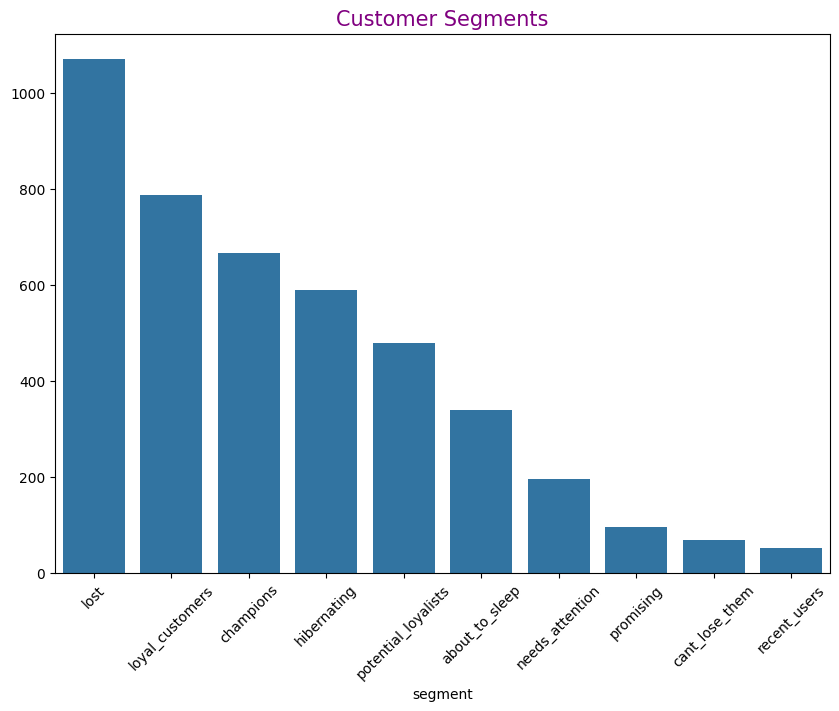

In [52]:
sgm= rfm["segment"].value_counts() #Count customers in each segment
plt.figure(figsize=(10,7))          
sns.barplot(x=sgm.index,y=sgm.values)
plt.xticks(rotation=45)      #Makes labels readable by rotating (for long names)
plt.title('Customer Segments',color = 'purple',fontsize=15)
plt.show()

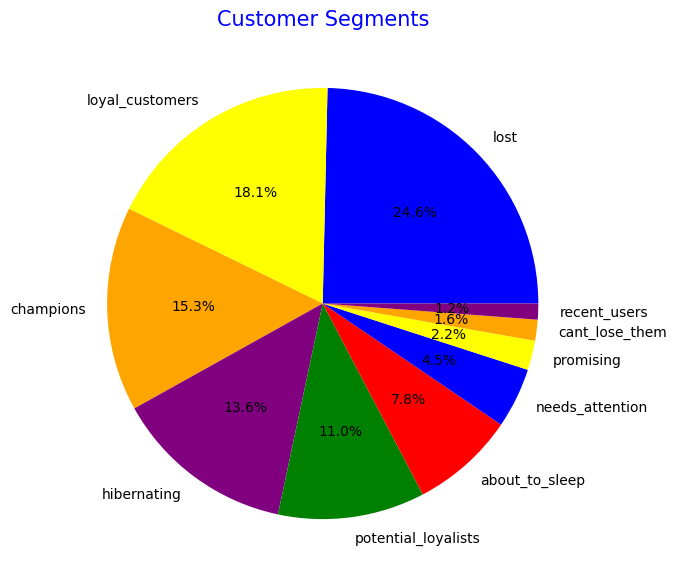

In [53]:
labels = rfm["segment"].value_counts().index
colors = ['blue','yellow','orange','purple','green','red']
sizes = rfm["segment"].value_counts().values


# visual
plt.figure(figsize = (7,7))
plt.pie(sizes, explode=None, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Customer Segments',color = 'blue',fontsize = 15)
plt.show()

In [54]:
sgm = rfm["segment"].value_counts()

sgm_dict = {k.replace("_", " ").title(): v for k, v in sgm.items()}

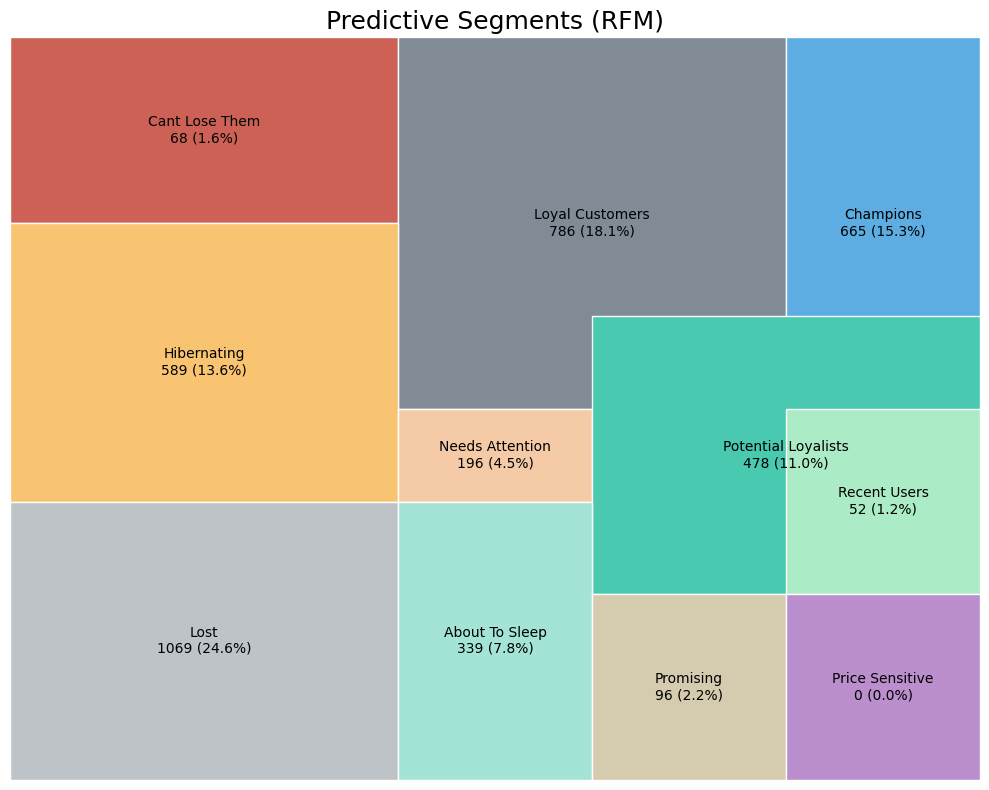

In [55]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(10, 8))

#  total customers
total = sum(sgm_dict.values())

def add_box(x, y, w, h, color, label):
    count = sgm_dict.get(label, 0)
    percent = (count / total) * 100 if total > 0 else 0
    
    text = f"{label}\n{count} ({percent:.1f}%)"
    
    ax.add_patch(Rectangle((x, y), w, h, facecolor=color, edgecolor='white'))
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=10)

# --- TOP ROW ---
add_box(0, 6, 4, 2, '#CD6155', "Cant Lose Them")
add_box(4, 4, 4, 4, '#808B96', "Loyal Customers")
add_box(8, 4, 2, 4, '#5DADE2', "Champions")

# --- MIDDLE ---
add_box(0, 3, 4, 3, '#F8C471', "Hibernating")
add_box(4, 3, 2, 1, '#F5CBA7', "Needs Attention")
add_box(6, 2, 4, 3, '#48C9B0', "Potential Loyalists")

# --- LOWER ---
add_box(0, 0, 4, 3, '#BDC3C7', "Lost")
add_box(4, 0, 2, 3, '#A3E4D7', "About To Sleep")
add_box(6, 0, 2, 2, '#D5CBAF', "Promising")
add_box(8, 2, 2, 2, '#ABEBC6', "Recent Users")
add_box(8, 0, 2, 2, '#BB8FCE', "Price Sensitive")

# Axis settings
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)

ax.set_xlabel("Recency score", fontsize=12)
ax.set_ylabel("Frequency & Monetary score", fontsize=12)

plt.title("Predictive Segments (RFM)", fontsize=18)
plt.axis('off')

plt.tight_layout()
plt.savefig('Predictive Segments (RFM).png', dpi=150)
plt.show()

In [56]:
# Treemap Visualization
df_treemap = rfm.groupby('segment').agg('count').reset_index()
df_treemap.head(10)



,segment,recency,frequency,monetary,recency_score,frequency_score,monetary_score,RFM_SCORE
0,about_to_sleep,339,339,339,339,339,339,339
1,cant_lose_them,68,68,68,68,68,68,68
2,champions,665,665,665,665,665,665,665
3,hibernating,589,589,589,589,589,589,589
4,lost,1069,1069,1069,1069,1069,1069,1069
5,loyal_customers,786,786,786,786,786,786,786
6,needs_attention,196,196,196,196,196,196,196
7,potential_loyalists,478,478,478,478,478,478,478
8,promising,96,96,96,96,96,96,96
9,recent_users,52,52,52,52,52,52,52


In [57]:
print("----------------- RFM segmentation complete.------------------------")

----------------- RFM segmentation complete.------------------------


In [58]:
# top spending customers

In [59]:
print("Columns in rfm:", rfm.columns.tolist())
print("Shape:", rfm.shape)
print(rfm.head(3))

Columns in rfm: ['recency', 'frequency', 'monetary', 'recency_score', 'frequency_score', 'monetary_score', 'RFM_SCORE', 'segment']
Shape: (4338, 8)
            recency  frequency  monetary recency_score frequency_score  \
CustomerID                                                               
12346           326          1   310.440             1               1   
12347            40          7  4310.000             4               5   
12348            76          4  1770.780             3               4   

           monetary_score RFM_SCORE          segment  
CustomerID                                            
12346                   2        11             lost  
12347                   5        45  loyal_customers  
12348                   4        34  loyal_customers  


In [60]:

rfm['r_score'] = rfm['recency_score']
rfm['f_score'] = rfm['frequency_score']
rfm['m_score'] = rfm['monetary_score']

rfm['segment'] = rfm['segment'].str.lower().str.replace(' ', '_')

In [61]:

rfm['spend_rank'] = rfm['monetary'].rank(pct=True)
top_spenders = rfm[rfm['spend_rank'] >= 0.80]
overlap      = top_spenders[top_spenders['segment'] == 'champions']
pct          = len(overlap) / len(top_spenders) * 100

print(f"Total customers    : {len(rfm):,}")
print(f"Top 20% spenders   : {len(top_spenders):,}")
print(f"Of those, Champions: {len(overlap):,}  ({pct:.1f}%)")

print("\n=== Top 10 spenders and their segments ===")
print(rfm.nlargest(10, 'monetary')
         [['recency_score','frequency_score','monetary_score','monetary','segment']]
         .to_string())

print("\n=== Segment distribution in top 20% spenders ===")
print(top_spenders['segment'].value_counts())

Total customers    : 4,338
Top 20% spenders   : 868
Of those, Champions: 376  (43.3%)

=== Top 10 spenders and their segments ===
           recency_score frequency_score monetary_score   monetary          segment
CustomerID                                                                         
14646                  5               5              5 266163.525        champions
18102                  5               5              5 231584.345        champions
14911                  5               5              5 138919.840        champions
17450                  5               5              5 131550.645        champions
12415                  4               5              5 120210.355  loyal_customers
14156                  5               5              5 115551.920        champions
17511                  5               5              5  90952.235        champions
13694                  4               5              5  63785.025  loyal_customers
16684                  5      

In [62]:
# ------------------------------- Cohort Analysis ---------------------------------

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392689 entries, 0 to 392688
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      392689 non-null  object        
 1   StockCode    392689 non-null  object        
 2   Description  392689 non-null  object        
 3   Quantity     392689 non-null  float64       
 4   InvoiceDate  392689 non-null  datetime64[ns]
 5   Price        392689 non-null  float64       
 6   CustomerID   392689 non-null  int64         
 7   Country      392689 non-null  object        
 8   TotalPrice   392689 non-null  float64       
 9   TotalAmount  392689 non-null  float64       
 10  Month        392689 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 33.0+ MB


In [64]:
# Assign cohort month
df['cohort_month'] = (df.groupby('CustomerID')['InvoiceDate']
                        .transform('min')
                        .dt.to_period('M'))
df['invoice_period'] = df['InvoiceDate'].dt.to_period('M')
df['period_number'] = (df['invoice_period'] - df['cohort_month']).apply(lambda x: x.n)

In [65]:
# Build retention matrix
cohort_data = (df.groupby(['cohort_month', 'period_number'])['CustomerID']
                 .nunique()
                 .reset_index()
                 .rename(columns={'CustomerID': 'customers'}))

cohort_pivot = cohort_data.pivot(
    index='cohort_month', columns='period_number', values='customers'
)
cohort_size  = cohort_pivot.iloc[:, 0]
retention    = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100


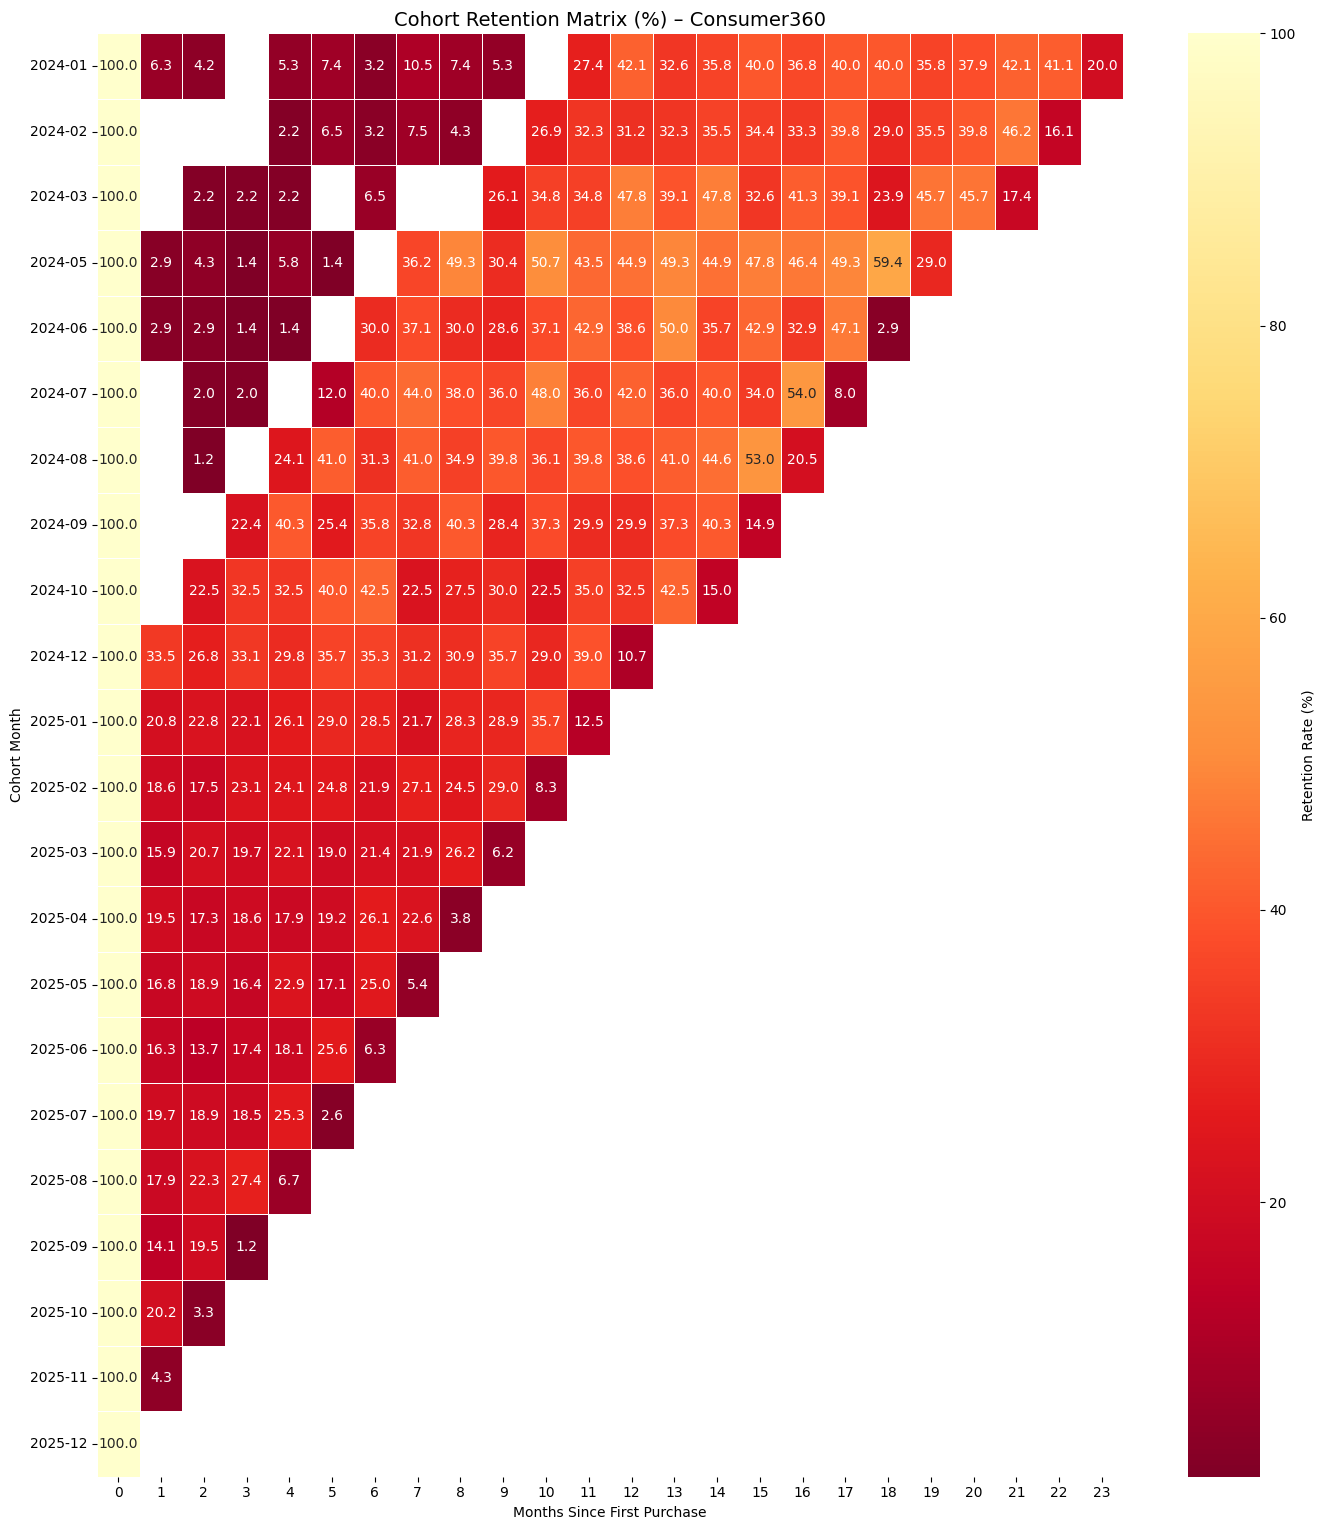

 Cohort analysis complete.


In [66]:
#Heatmap
fig, ax = plt.subplots(figsize=(14, max(5, len(retention) * 0.7)))
sns.heatmap(
    retention, annot=True, fmt='.1f',
    cmap='YlOrRd_r', linewidths=0.5,
    cbar_kws={'label': 'Retention Rate (%)'},
    ax=ax
)
ax.set_title('Cohort Retention Matrix (%) – Consumer360', fontsize=14)
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort Month')
plt.tight_layout()
plt.savefig('cohort_retention.png', dpi=150)
plt.show()
print(" Cohort analysis complete.")

In [67]:
 # ------------------------Market Basket Analysis (mlxtend Apriori)----------------------

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392689 entries, 0 to 392688
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Invoice         392689 non-null  object        
 1   StockCode       392689 non-null  object        
 2   Description     392689 non-null  object        
 3   Quantity        392689 non-null  float64       
 4   InvoiceDate     392689 non-null  datetime64[ns]
 5   Price           392689 non-null  float64       
 6   CustomerID      392689 non-null  int64         
 7   Country         392689 non-null  object        
 8   TotalPrice      392689 non-null  float64       
 9   TotalAmount     392689 non-null  float64       
 10  Month           392689 non-null  object        
 11  cohort_month    392689 non-null  period[M]     
 12  invoice_period  392689 non-null  period[M]     
 13  period_number   392689 non-null  int64         
dtypes: datetime64[ns](1), float64(4), in

In [69]:
# Market Basket
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder


In [70]:
# Building basket matrix 
# Filter top 100 products
top_products = df['Description'].value_counts().head(100).index
df_filtered = df[df['Description'].isin(top_products)]

# Build basket
basket = (df_filtered.groupby(['Invoice', 'Description'])['Quantity']
            .sum()
            .unstack(fill_value=0))

# Convert to boolean
basket_bin = (basket > 0)

# Use FP-Growth (best)
from mlxtend.frequent_patterns import fpgrowth

freq_items = fpgrowth(
    basket_bin,
    min_support=0.05,
    use_colnames=True
)

print(freq_items.head())

   support                              itemsets
0    0.131  (WHITE HANGING HEART T-LIGHT HOLDER)
1    0.091       (ASSORTED COLOUR BIRD ORNAMENT)
2    0.058            (JAM MAKING SET WITH JARS)
3    0.073                             (POSTAGE)
4    0.058            (ALARM CLOCK BAKELIKE RED)


In [71]:
#  Binarise
basket_bin.sum(axis=1).value_counts().head(10)

1     2889
2     2344
3     1960
4     1570
5     1254
6     1017
7      836
8      617
9      552
10     422
Name: count, dtype: int64

In [72]:
#Apriori frequent itemsets 

n_transactions = len(basket_bin)
min_sup = max(0.01, 2 / n_transactions)   

freq_items = apriori(basket_bin,
                     min_support=min_sup,
                     use_colnames=True,
                     max_len=3)

print(f"Frequent itemsets found: {len(freq_items):,}  (min_support={min_sup:.3f})")


Frequent itemsets found: 497  (min_support=0.010)



── Top 10 Association Rules ──
                                                 antecedents_str                                                  consequents_str  support  confidence   lift
                                  PINK REGENCY TEACUP AND SAUCER        GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER    0.018       0.487 19.668
       GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER                                   PINK REGENCY TEACUP AND SAUCER    0.018       0.725 19.668
                                  PINK REGENCY TEACUP AND SAUCER GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER    0.026       0.701 19.568
GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER                                   PINK REGENCY TEACUP AND SAUCER    0.026       0.721 19.568
 PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER                                  GREEN REGENCY TEACUP AND SAUCER    0.026       0.894 19.537
                    

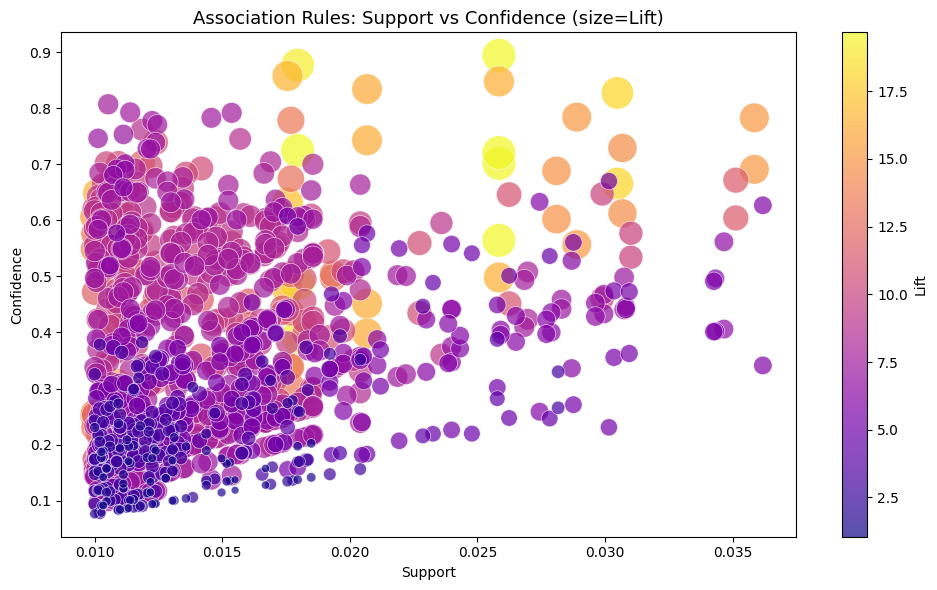


Rules before dedup: 1,264
Rules after dedup : 396

  MARKET BASKET — BUSINESS RECOMMENDATIONS
                 rule_count  avg_lift  avg_conf  max_lift
family                                                   
Regency Tea Set          13    10.890     0.630    19.540
Other                   383     6.130     0.420    16.250

── Top 3 Actionable Bundles ──

Bundle 1:
  Buy : PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER
  Also: GREEN REGENCY TEACUP AND SAUCER
  Confidence: 89.4%  |  Lift: 19.5

Bundle 2:
  Buy : PINK REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER
  Also: GREEN REGENCY TEACUP AND SAUCER
  Confidence: 87.7%  |  Lift: 19.2

Bundle 3:
  Buy : PINK REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER
  Also: ROSES REGENCY TEACUP AND SAUCER
  Confidence: 85.8%  |  Lift: 16.5

── Rule quality tiers ──
  Strong  (lift>10, conf>0.6): 31 rules
  Medium  (lift 3–10, conf>0.5): 115 rules
  Total rules generated      : 396 rules

 Market basket analysis comple

In [73]:
from mlxtend.frequent_patterns import association_rules
import matplotlib.pyplot as plt

# ============================================================
# 1. GENERATE ASSOCIATION RULES
# ============================================================
if len(freq_items) > 0:

    rules = association_rules(
        freq_items,
        metric='lift',
        min_threshold=1.0
    )

    rules = rules.sort_values('lift', ascending=False)

    # Convert frozenset → string (for readability)
    rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

    print("\n── Top 10 Association Rules ──")
    print(rules[['antecedents_str','consequents_str',
                 'support','confidence','lift']]
          .head(10)
          .to_string(index=False))

    # ============================================================
    # 2. VISUALIZATION (SCATTER PLOT)
    # ============================================================
    fig, ax = plt.subplots(figsize=(10, 6))

    scatter = ax.scatter(
        rules['support'],
        rules['confidence'],
        c=rules['lift'],
        cmap='plasma',
        s=rules['lift'] * 30,
        alpha=0.7,
        edgecolors='white',
        linewidth=0.5
    )

    plt.colorbar(scatter, ax=ax, label='Lift')
    ax.set_xlabel('Support')
    ax.set_ylabel('Confidence')
    ax.set_title('Association Rules: Support vs Confidence (size=Lift)', fontsize=13)

    plt.tight_layout()
    plt.savefig('market_basket_rules.png', dpi=150)
    plt.show()

    # ============================================================
    # 3. REMOVE DUPLICATE RULES (A→B and B→A)
    # ============================================================
    rules['pair_key'] = rules.apply(
        lambda r: frozenset(list(r['antecedents']) + list(r['consequents'])),
        axis=1
    )

    rules_deduped = (
        rules.sort_values('confidence', ascending=False)
             .drop_duplicates(subset='pair_key')
             .drop(columns='pair_key')
             .reset_index(drop=True)
    )

    print(f"\nRules before dedup: {len(rules):,}")
    print(f"Rules after dedup : {len(rules_deduped):,}")

    # Save cleaned rules
    rules_deduped[['antecedents_str','consequents_str',
                   'support','confidence','lift']] \
        .head(20) \
        .to_csv('top_association_rules.csv', index=False)

    # ============================================================
    # 4. BUSINESS RECOMMENDATIONS
    # ============================================================
    print("\n" + "=" * 60)
    print("  MARKET BASKET — BUSINESS RECOMMENDATIONS")
    print("=" * 60)

    rules = rules_deduped.copy()

    # Group by product family
    rules['family'] = rules['antecedents_str'].apply(
        lambda x: 'Regency Tea Set' if 'REGENCY' in x.upper()
                  else 'Other'
    )

    family_summary = (rules.groupby('family')
                            .agg(
                                rule_count=('lift', 'count'),
                                avg_lift=('lift', 'mean'),
                                avg_conf=('confidence', 'mean'),
                                max_lift=('lift', 'max')
                            )
                            .round(2)
                            .sort_values('avg_lift', ascending=False))

    print(family_summary)

    # ============================================================
    # 5. TOP BUNDLES
    # ============================================================
    print("\n── Top 3 Actionable Bundles ──")

    seen = set()
    count = 0

    for _, row in rules.iterrows():
        key = frozenset(list(row['antecedents']) + list(row['consequents']))

        if key not in seen:
            seen.add(key)

            print(f"\nBundle {count+1}:")
            print(f"  Buy : {row['antecedents_str']}")
            print(f"  Also: {row['consequents_str']}")
            print(f"  Confidence: {row['confidence']:.1%}  |  Lift: {row['lift']:.1f}")

            count += 1

        if count == 3:
            break

    # ============================================================
    # 6. RULE QUALITY ANALYSIS
    # ============================================================
    strong = rules[(rules['lift'] > 10) & (rules['confidence'] > 0.6)]
    medium = rules[(rules['lift'].between(3, 10)) & (rules['confidence'] > 0.5)]

    print(f"\n── Rule quality tiers ──")
    print(f"  Strong  (lift>10, conf>0.6): {len(strong):,} rules")
    print(f"  Medium  (lift 3–10, conf>0.5): {len(medium):,} rules")
    print(f"  Total rules generated      : {len(rules):,} rules")

    print("\n Market basket analysis complete.")

else:
    print(" No frequent itemsets found. Try lowering min_support.")

In [74]:
# -------------- Predictive CLV (BG/NBD + Gamma-Gamma) --------------------

In [75]:
# CLV = Expected number of future purchases × Expected spend per purchase 
''' CLV (Customer Lifetime Value) means:
     The total money a customer is expected to spend with our business over their entire relationship. '''

' CLV (Customer Lifetime Value) means:\n     The total money a customer is expected to spend with our business over their entire relationship. '

In [76]:
from lifetimes.utils import summary_data_from_transaction_data #converts raw transaction data into customer-level data
from lifetimes import BetaGeoFitter, GammaGammaFitter
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [77]:
# Clean raw df
df_clv = df.copy()
df_clv = df_clv[df_clv['CustomerID'].notna()]
df_clv = df_clv[df_clv['TotalPrice'] > 0]
df_clv = df_clv[~df_clv['Invoice'].astype(str).str.startswith('C')]    #"C" = Cancelled orders
df_clv['CustomerID']  = df_clv['CustomerID'].astype(int)
df_clv['InvoiceDate'] = pd.to_datetime(df_clv['InvoiceDate'])

print(f"Clean rows         : {len(df_clv):,}")
print(f"Unique customers   : {df_clv['CustomerID'].nunique():,}")


Clean rows         : 392,689
Unique customers   : 4,338


In [78]:
# Snapshot = 1 day after last transaction
SNAPSHOT_DATE = df_clv['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date      : {SNAPSHOT_DATE.date()}")


Snapshot date      : 2025-12-11


In [79]:
# Build summary in WEEKS (freq='W' — critical for convergence)
summary_raw = summary_data_from_transaction_data(
    df_clv,
    customer_id_col    = 'CustomerID',
    datetime_col       = 'InvoiceDate',
    monetary_value_col = 'TotalPrice',
    observation_period_end = SNAPSHOT_DATE,
    freq = 'W'  # All time calculations are in weeks
)

one_time = (summary_raw['frequency'] == 0).sum()  #One-time buyers
repeat   = (summary_raw['frequency'] >  0).sum()  #Repeat buyers
print(f"One-time buyers    : {one_time:,} ({one_time/len(summary_raw):.1%})")
print(f"Repeat buyers      : {repeat:,}   ({repeat/len(summary_raw):.1%})")


One-time buyers    : 1,570 (36.2%)
Repeat buyers      : 2,768   (63.8%)


In [80]:
# Repeat customers only
summary_repeat = summary_raw[summary_raw['frequency'] > 0].copy()
print(f"Repeat customers (frequency > 0): {len(summary_repeat):,}")

# ── Remove impossible rows ────────────────────────────────────────
before = len(summary_repeat)
summary_repeat = summary_repeat[
    (summary_repeat['recency'] <= summary_repeat['T']) &
    (summary_repeat['T'] > 0) &
    (summary_repeat['monetary_value'] > 0)
].copy()
print(f"Removed {before - len(summary_repeat)} invalid rows")

# ── Cap outliers at 99th percentile ──────────────────────────────
freq_cap = summary_repeat['frequency'].quantile(0.99)
mon_cap  = summary_repeat['monetary_value'].quantile(0.99)

summary_repeat = summary_repeat[
    summary_repeat['frequency'] <= freq_cap
].copy()
summary_repeat['monetary_value'] = summary_repeat['monetary_value'].clip(upper=mon_cap)

print(f"\nFrequency cap (99th pct) : {freq_cap:.0f} orders")
print(f"Monetary cap  (99th pct) : £{mon_cap:.2f}")
print(f"Final modelling set      : {len(summary_repeat):,} customers")

print("\n=== Final summary stats ===")
print(summary_repeat[['frequency','recency','T','monetary_value']].describe().round(2))

# ── Sanity check: T should now be ~10–100 weeks, not 100–700 ─────
# T = customer lifetime (age) = Snapshot Date – First Purchase Date
print(f"\nT range (weeks): {summary_repeat['T'].min():.1f} – {summary_repeat['T'].max():.1f}")
print("Good" if summary_repeat['T'].max() < 200 else "  T still very large — check freq='W' was applied")

Repeat customers (frequency > 0): 2,768
Removed 0 invalid rows

Frequency cap (99th pct) : 24 orders
Monetary cap  (99th pct) : £2241.89
Final modelling set      : 2,742 customers

=== Final summary stats ===
       frequency  recency        T  monetary_value
count   2742.000 2742.000 2742.000        2742.000
mean       3.810   34.980   44.570         401.170
std        3.840   22.780   21.370         342.070
min        1.000    1.000    2.000           1.000
25%        1.000   18.000   31.000         194.430
50%        2.000   32.000   43.000         314.660
75%        5.000   45.000   51.000         469.420
max       24.000  100.000  100.000        2241.890

T range (weeks): 2.0 – 100.0
Good


In [81]:
# Fit BG/NBD Model (Purchase Frequency)
''' Model learns: How often customers will purchase in future '''

bgf = None
for p in [0.0, 0.001, 0.01, 0.05, 0.1, 0.5]:             #penalty strengths
    try:
        _bgf = BetaGeoFitter(penalizer_coef=p)
        _bgf.fit(
            summary_raw['frequency'],
            summary_raw['recency'],
            summary_raw['T']
        )
        bgf = _bgf
        print(f" BG/NBD converged — penalizer={p}")
        print(bgf.summary)
        break
    except Exception as e:
        print(f"    penalizer={p} → {str(e)[:70]}")

if bgf is None:
    raise RuntimeError("BG/NBD failed at all penalizers — check input data in Cell 2.")

# Warn if a≈0 (no churn signal detected)
if bgf.params_['a'] < 0.01:
    print("\n  WARNING: BG/NBD 'a' parameter ≈ 0")
    print("   The model detected no churn in this observation window.")
    print("   prob_alive will be 1.0 for all customers.")

 BG/NBD converged — penalizer=0.0
           coef  se(coef)  lower 95% bound  upper 95% bound
r         1.076     0.039            1.000            1.152
alpha    16.875     0.666           15.571           18.180
a         0.000       NaN              NaN              NaN
b     15295.782       NaN              NaN              NaN

   The model detected no churn in this observation window.
   prob_alive will be 1.0 for all customers.


In [82]:
# Fit Gamma-Gamma Model (Spend per Transaction)
 
   # ''' how much customers spend per purchase using the Gamma-Gamma model. '''


corr = summary_repeat[['frequency', 'monetary_value']].corr().iloc[0, 1]
print(f"Frequency–Monetary correlation: {corr:.3f}",
      " OK" if abs(corr) < 0.3 else "  > 0.3, results are indicative")

ggf = None
for p in [0.0, 0.001, 0.01, 0.05, 0.1, 0.5]:
    try:
        _ggf = GammaGammaFitter(penalizer_coef=p)
        _ggf.fit(
            summary_repeat['frequency'],
            summary_repeat['monetary_value']
        )
        ggf = _ggf
        print(f"  Gamma-Gamma converged — penalizer={p}")
        print(ggf.summary)
        break
    except Exception as e:
        print(f"    penalizer={p} → {str(e)[:70]}")

if ggf is None:
    raise RuntimeError("Gamma-Gamma failed at all penalizers — check monetary_value distribution.")


Frequency–Monetary correlation: 0.176  OK
  Gamma-Gamma converged — penalizer=0.0
     coef  se(coef)  lower 95% bound  upper 95% bound
p   2.218     0.125            1.973            2.463
q   4.038     0.185            3.675            4.401
v 565.207    55.518          456.392          674.022


In [83]:
# ── Predictions ───────────────────────────────────────────────────
# Predicts how many times each customer will buy in the next 52 weeks (1 year)
# CLV = Expected purchases × Expected spend × Discount factor

summary_repeat['pred_purchases_52w'] = bgf.predict(
    52,
    summary_repeat['frequency'],
    summary_repeat['recency'],
    summary_repeat['T']
)

summary_repeat['prob_alive'] = bgf.conditional_probability_alive(
    summary_repeat['frequency'],
    summary_repeat['recency'],
    summary_repeat['T']
)

summary_repeat['clv_12m'] = ggf.customer_lifetime_value(
    bgf,
    summary_repeat['frequency'],
    summary_repeat['recency'],
    summary_repeat['T'],
    summary_repeat['monetary_value'],
    time=12,
    freq='W',           
    discount_rate=0.01
)

print("── Top 10 by 12-Month CLV ──")
print(summary_repeat.sort_values('clv_12m', ascending=False)
                    .head(10)
                    [['frequency','recency','T','monetary_value',
                      'pred_purchases_52w','prob_alive','clv_12m']]
                    .round(2).to_string())

# ── Merge with RFM ────────────────────────────────────────────────
rfm_clv = rfm.merge(
    summary_repeat[['pred_purchases_52w','prob_alive','clv_12m']],
    left_on='CustomerID',
    right_index=True,
    how='left'
)
print(f"\n  CLV merged: {rfm_clv['clv_12m'].notna().sum():,} customers")
print(f"   One-time buyers (no CLV): {rfm_clv['clv_12m'].isna().sum():,}")

── Top 10 by 12-Month CLV ──
            frequency  recency       T  monetary_value  pred_purchases_52w  prob_alive   clv_12m
CustomerID                                                                                      
14298          21.000   44.000  52.000        2241.890              16.670       1.000 33384.610
17450          22.000   73.000  74.000        2241.890              13.200       1.000 26508.210
18102          20.000   72.000  74.000        2241.890              12.060       1.000 24096.910
17389          24.000   47.000  48.000        1309.610              20.100       1.000 23839.250
14096          13.000   42.000  44.000        2241.890              12.020       1.000 23378.690
12415          14.000   45.000  49.000        2241.890              11.900       1.000 23266.040
13098          20.000   44.000  46.000        1411.680              17.430       1.000 22091.140
17511          22.000   99.000 100.000        2241.890              10.270       1.000 20611.210
1

In [84]:
# Runing this to validate model health
print("=== BG/NBD Parameters ===")
print(f"r     = {bgf.params_['r']:.3f}   (purchase rate shape — healthy if > 0.1)")
print(f"alpha = {bgf.params_['alpha']:.3f} (purchase rate scale)")
print(f"a     = {bgf.params_['a']:.3f}   (dropout rate shape — WARNING if ~0)")
print(f"b     = {bgf.params_['b']:.3f}   (dropout rate scale)")

print("\n=== Gamma-Gamma Parameters ===")
print(f"p = {ggf.params_['p']:.3f}")
print(f"q = {ggf.params_['q']:.3f}")
print(f"v = {ggf.params_['v']:.3f}")

print("\n=== Key Stats ===")
print(f"Avg predicted purchases (52w) : {summary_repeat['pred_purchases_52w'].mean():.2f}")
print(f"Avg probability alive         : {summary_repeat['prob_alive'].mean():.2%}")
print(f"Avg 12-month CLV              : £{summary_repeat['clv_12m'].mean():.2f}")
print(f"Median 12-month CLV           : £{summary_repeat['clv_12m'].median():.2f}")
print(f"Total predicted revenue (12m) : £{summary_repeat['clv_12m'].sum():,.0f}")

=== BG/NBD Parameters ===
r     = 1.076   (purchase rate shape — healthy if > 0.1)
alpha = 16.875 (purchase rate scale)
a     = 0.000   (dropout rate shape — WARNING if ~0)
b     = 15295.782   (dropout rate scale)

=== Gamma-Gamma Parameters ===
p = 2.218
q = 4.038
v = 565.207

=== Key Stats ===
Avg predicted purchases (52w) : 4.14
Avg probability alive         : 100.00%
Avg 12-month CLV              : £1704.86
Median 12-month CLV           : £1172.10
Total predicted revenue (12m) : £4,674,721


In [85]:
#  how many customers hit the monetary cap? ──────────────
# Cap = maximum allowed value (Cap is a limit applied to data so that extremely large values do not distort the model.)

capped = (summary_repeat['monetary_value'] == summary_repeat['monetary_value'].max()).sum()
print(f"Customers at monetary cap (£2241.89): {capped}")

# If capped > 20, raise cap to 99.5th percentile
if capped > 20:
    print(" Too many customers hitting cap — recapping at 99.5th pct")
    mon_cap_new = summary_raw[summary_raw['frequency'] > 0]['monetary_value'].quantile(0.995)
    summary_repeat['monetary_value'] = summary_repeat['monetary_value'].clip(upper=mon_cap_new)
    print(f"New cap: £{mon_cap_new:.2f}")

    # Refit Gamma-Gamma with new cap
    ggf2 = GammaGammaFitter(penalizer_coef=0.0)
    ggf2.fit(summary_repeat['frequency'], summary_repeat['monetary_value'])
    summary_repeat['clv_12m'] = ggf2.customer_lifetime_value(
        bgf,
        summary_repeat['frequency'],
        summary_repeat['recency'],
        summary_repeat['T'],
        summary_repeat['monetary_value'],
        time=12, freq='W', discount_rate=0.01
    )
    print("CLV recalculated with revised cap")

Customers at monetary cap (£2241.89): 24
 Too many customers hitting cap — recapping at 99.5th pct
New cap: £3614.48
CLV recalculated with revised cap


In [86]:
print("\n" + "=" * 55)
print("   CLV PREDICTION + CHURN ADJUSTMENT")
print("=" * 55)

# ── Raw CLV predictions ──────────────────────────────────────────
summary_repeat['pred_purchases_52w'] = bgf.predict(
    52,
    summary_repeat['frequency'],
    summary_repeat['recency'],
    summary_repeat['T']
)

summary_repeat['prob_alive_raw'] = bgf.conditional_probability_alive(
    summary_repeat['frequency'],
    summary_repeat['recency'],
    summary_repeat['T']
)

summary_repeat['clv_12m_raw'] = ggf.customer_lifetime_value(
    bgf,
    summary_repeat['frequency'],
    summary_repeat['recency'],
    summary_repeat['T'],
    summary_repeat['monetary_value'],
    time=12,
    freq='W',
    discount_rate=0.01
)

# ── Recency-gap churn adjustment ─────────────────────────────────
# When BG/NBD a≈0, we use observed silence to estimate survival
summary_repeat['recency_gap'] = summary_repeat['T'] - summary_repeat['recency']

def survival_prob(gap_weeks):
    """
    Tiered survival probability based on weeks of silence.
    Calibrate these thresholds to your business context.
    """
    if   gap_weeks <= 4:  return 0.98   # bought very recently
    elif gap_weeks <= 8:  return 0.90   # warm
    elif gap_weeks <= 12: return 0.75   # at risk
    elif gap_weeks <= 26: return 0.50   # fading
    else:                 return 0.25   # likely churned

summary_repeat['prob_alive_adjusted'] = summary_repeat['recency_gap'].apply(survival_prob)
summary_repeat['clv_12m_adjusted']    = (
    summary_repeat['clv_12m_raw'] * summary_repeat['prob_alive_adjusted']
)

# ── Survival tier label for Power BI ────────────────────────────
def survival_label(gap_weeks):
    if   gap_weeks <= 4:  return 'Active'
    elif gap_weeks <= 8:  return 'Warm'
    elif gap_weeks <= 12: return 'At Risk'
    elif gap_weeks <= 26: return 'Fading'
    else:                 return 'Likely Churned'

summary_repeat['activity_status'] = summary_repeat['recency_gap'].apply(survival_label)

# ── Print tier breakdown ─────────────────────────────────────────
print("=== Survival tier distribution ===")
tier_map = {0.98:'Active (≤4w)', 0.90:'Warm (5-8w)',
            0.75:'At risk (9-12w)', 0.50:'Fading (13-26w)', 0.25:'Likely churned (>26w)'}
for prob, count in summary_repeat['prob_alive_adjusted'].value_counts().sort_index(ascending=False).items():
    print(f"  {tier_map.get(prob, str(prob)):<28}: {count:,}")

print(f"\nRaw CLV avg        : £{summary_repeat['clv_12m_raw'].mean():,.0f}")
print(f"Adjusted CLV avg   : £{summary_repeat['clv_12m_adjusted'].mean():,.0f}")
print(f"Raw total (12m)    : £{summary_repeat['clv_12m_raw'].sum():,.0f}")
print(f"Adjusted total(12m): £{summary_repeat['clv_12m_adjusted'].sum():,.0f}")
print(f"Reduction          : {1 - summary_repeat['clv_12m_adjusted'].sum()/summary_repeat['clv_12m_raw'].sum():.1%}")



   CLV PREDICTION + CHURN ADJUSTMENT
=== Survival tier distribution ===
  Active (≤4w)                : 1,252
  Warm (5-8w)                 : 447
  At risk (9-12w)             : 319
  Fading (13-26w)             : 492
  Likely churned (>26w)       : 232

Raw CLV avg        : £1,705
Adjusted CLV avg   : £1,477
Raw total (12m)    : £4,674,721
Adjusted total(12m): £4,050,908
Reduction          : 13.3%


In [87]:
# ---------------- Merge CLV + Churn into RFM --------------------


print("\n" + "=" * 55)
print("  MERGE INTO RFM TABLE")
print("=" * 55)

rfm_clv = rfm.merge(
    summary_repeat[[
        'pred_purchases_52w',
        'prob_alive_raw',
        'prob_alive_adjusted',
        'clv_12m_raw',
        'clv_12m_adjusted',
        'recency_gap',
        'activity_status'
    ]],
    left_on    = 'CustomerID',
    right_index= True,
    how        = 'left'
)

print(f"Total customers    : {len(rfm_clv):,}")
print(f"CLV modelled       : {rfm_clv['clv_12m_adjusted'].notna().sum():,}")
print(f"One-time buyers    : {rfm_clv['clv_12m_adjusted'].isna().sum():,}  (no CLV — first purchase only)")



  MERGE INTO RFM TABLE
Total customers    : 4,338
CLV modelled       : 2,742
One-time buyers    : 1,596  (no CLV — first purchase only)


In [88]:
# ── Fill one-time buyers with 0 for Power BI ────────────────────
rfm_clv['clv_12m_raw']       = rfm_clv['clv_12m_raw'].fillna(0)
rfm_clv['clv_12m_adjusted']  = rfm_clv['clv_12m_adjusted'].fillna(0)
rfm_clv['pred_purchases_52w']= rfm_clv['pred_purchases_52w'].fillna(0)
rfm_clv['prob_alive_adjusted']= rfm_clv['prob_alive_adjusted'].fillna(0)
rfm_clv['recency_gap']       = rfm_clv['recency_gap'].fillna(0)
rfm_clv['activity_status']   = rfm_clv['activity_status'].fillna('One-Time Buyer')


In [89]:

#  ----------------- Churn Risk Flag ---------------------------


print("\n" + "=" * 55)
print("  CHURN RISK FLAGGING")
print("=" * 55)

def flag_churn(row):
    seg = str(row.get('segment', '')).lower().replace(' ', '_')
    gap = row.get('recency_gap', 0)
    # Segment-based rules
    if seg in ["cant_lose_them", "can't_lose_them", "hibernating", "lost"]:
        return 'High Risk'
    elif seg in ['needs_attention', 'about_to_sleep']:
        return 'Medium Risk'
    # Recency-gap rules (catches one-time buyers and silent customers)
    elif gap > 26 or row.get('activity_status') == 'Likely Churned':
        return 'High Risk'
    elif gap > 12 or row.get('activity_status') == 'At Risk':
        return 'Medium Risk'
    elif row.get('activity_status') == 'One-Time Buyer':
        return 'High Risk'
    else:
        return 'Low Risk'

rfm_clv['churn_risk'] = rfm_clv.apply(flag_churn, axis=1)

print("=== Churn risk distribution ===")
print(rfm_clv['churn_risk'].value_counts().to_string())



  CHURN RISK FLAGGING
=== Churn risk distribution ===
churn_risk
High Risk      2014
Low Risk       1604
Medium Risk     720


In [90]:

# ------------------ CLV Tier Segmentation -----------------------


print("\n" + "=" * 55)
print("   CLV TIER LABELS")
print("=" * 55)

# Compute thresholds on repeat buyers only (exclude 0s)
repeat_mask = rfm_clv['clv_12m_adjusted'] > 0
p33 = rfm_clv.loc[repeat_mask, 'clv_12m_adjusted'].quantile(0.33)
p66 = rfm_clv.loc[repeat_mask, 'clv_12m_adjusted'].quantile(0.66)

def clv_tier(val):
    if val == 0:      return 'No CLV (One-Time)'
    elif val <= p33:  return 'Low CLV'
    elif val <= p66:  return 'Mid CLV'
    else:             return 'High CLV'

rfm_clv['clv_tier'] = rfm_clv['clv_12m_adjusted'].apply(clv_tier)

print(f"CLV tier thresholds (repeat buyers only):")
print(f"  Low  CLV : £0 – £{p33:,.0f}")
print(f"  Mid  CLV : £{p33:,.0f} – £{p66:,.0f}")
print(f"  High CLV : £{p66:,.0f}+")
print(f"\n{rfm_clv['clv_tier'].value_counts().to_string()}")



   CLV TIER LABELS
CLV tier thresholds (repeat buyers only):
  Low  CLV : £0 – £655
  Mid  CLV : £655 – £1,361
  High CLV : £1,361+

clv_tier
No CLV (One-Time)    1596
High CLV              932
Mid CLV               905
Low CLV               905



  PLOTS


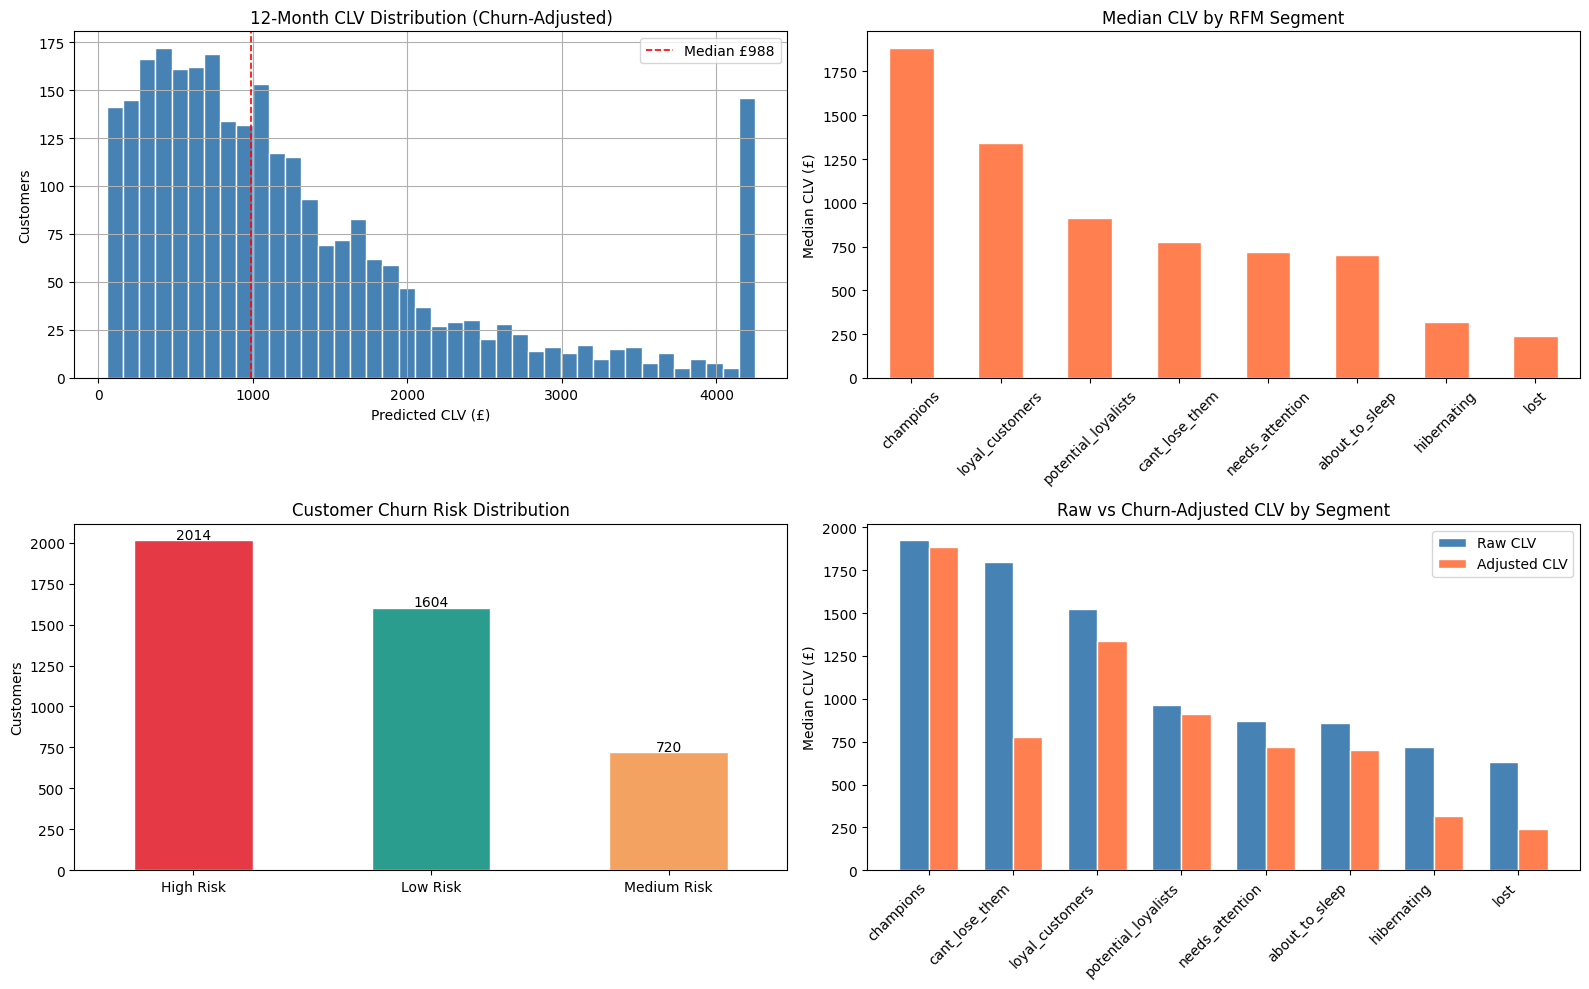

✅  clv_churn_dashboard.png saved


In [91]:

#  ------------------ Visualisations -------------------------


print("\n" + "=" * 55)
print("  PLOTS")
print("=" * 55)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Plot 1: CLV Distribution (adjusted) ─────────────────────────
repeat_clv = rfm_clv[rfm_clv['clv_12m_adjusted'] > 0]['clv_12m_adjusted']
repeat_clv.clip(upper=repeat_clv.quantile(0.95)).hist(
    bins=40, color='steelblue', edgecolor='white', ax=axes[0,0])
axes[0,0].set_title('12-Month CLV Distribution (Churn-Adjusted)')
axes[0,0].set_xlabel('Predicted CLV (£)')
axes[0,0].set_ylabel('Customers')
axes[0,0].axvline(repeat_clv.median(), color='red',
                  linestyle='--', linewidth=1.2, label=f'Median £{repeat_clv.median():,.0f}')
axes[0,0].legend()

# ── Plot 2: Median CLV by Segment ────────────────────────────────
seg_clv = (rfm_clv[rfm_clv['clv_12m_adjusted'] > 0]
           .groupby('segment')['clv_12m_adjusted']
           .median()
           .sort_values(ascending=False))
seg_clv.plot(kind='bar', color='coral', edgecolor='white', rot=45, ax=axes[0,1])
axes[0,1].set_title('Median CLV by RFM Segment')
axes[0,1].set_ylabel('Median CLV (£)')
axes[0,1].set_xlabel('')

# ── Plot 3: Churn Risk Distribution ──────────────────────────────
churn_counts = rfm_clv['churn_risk'].value_counts()
colors = {'High Risk':'#E63946', 'Medium Risk':'#F4A261', 'Low Risk':'#2A9D8F'}
churn_counts.plot(
    kind='bar',
    color=[colors.get(c, 'gray') for c in churn_counts.index],
    edgecolor='white', rot=0, ax=axes[1,0])
axes[1,0].set_title('Customer Churn Risk Distribution')
axes[1,0].set_ylabel('Customers')
axes[1,0].set_xlabel('')
for i, v in enumerate(churn_counts):
    axes[1,0].text(i, v + 10, str(v), ha='center', fontsize=10)

# ── Plot 4: Raw vs Adjusted CLV by Segment ───────────────────────
compare = rfm_clv[rfm_clv['clv_12m_raw'] > 0].groupby('segment').agg(
    raw_clv      = ('clv_12m_raw',      'median'),
    adjusted_clv = ('clv_12m_adjusted', 'median')
).sort_values('raw_clv', ascending=False)
x = range(len(compare))
w = 0.35
axes[1,1].bar([i - w/2 for i in x], compare['raw_clv'],
              width=w, label='Raw CLV',      color='steelblue', edgecolor='white')
axes[1,1].bar([i + w/2 for i in x], compare['adjusted_clv'],
              width=w, label='Adjusted CLV', color='coral',     edgecolor='white')
axes[1,1].set_xticks(list(x))
axes[1,1].set_xticklabels(compare.index, rotation=45, ha='right')
axes[1,1].set_title('Raw vs Churn-Adjusted CLV by Segment')
axes[1,1].set_ylabel('Median CLV (£)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('clv_churn_dashboard.png', dpi=150)
plt.show()
print("✅  clv_churn_dashboard.png saved")


In [92]:

# --------------- Final Business Summary -----------------------------


print("\n" + "=" * 55)
print("  CONSUMER360 — FINAL CLV & CHURN SUMMARY")
print("=" * 55)

repeat_only = rfm_clv[rfm_clv['clv_12m_adjusted'] > 0]

print(f"\n  Total customers            : {len(rfm_clv):,}")
print(f"  Repeat buyers (CLV scored) : {len(repeat_only):,}")
print(f"  One-time buyers            : {rfm_clv['clv_12m_adjusted'].eq(0).sum():,}")

print(f"\n  ── CLV Metrics ──")
print(f"  Raw avg CLV (12m)          : £{rfm_clv['clv_12m_raw'].mean():,.0f}")
print(f"  Adjusted avg CLV (12m)     : £{rfm_clv['clv_12m_adjusted'].mean():,.0f}")
print(f"  Raw total revenue (12m)    : £{rfm_clv['clv_12m_raw'].sum():,.0f}")
print(f"  Adjusted total (12m)       : £{rfm_clv['clv_12m_adjusted'].sum():,.0f}")
print(f"  Churn discount applied     : {1 - rfm_clv['clv_12m_adjusted'].sum()/rfm_clv['clv_12m_raw'].replace(0,np.nan).sum():.1%}")

print(f"\n  ── Churn Risk ──")
for risk, count in rfm_clv['churn_risk'].value_counts().items():
    pct = count / len(rfm_clv) * 100
    print(f"  {risk:<15}: {count:,}  ({pct:.1f}%)")

print(f"\n  ── CLV Tiers ──")
for tier, count in rfm_clv['clv_tier'].value_counts().items():
    pct = count / len(rfm_clv) * 100
    print(f"  {tier:<22}: {count:,}  ({pct:.1f}%)")

print(f"\n  ── Activity Status ──")
for status, count in rfm_clv['activity_status'].value_counts().items():
    print(f"  {status:<20}: {count:,}")



  CONSUMER360 — FINAL CLV & CHURN SUMMARY

  Total customers            : 4,338
  Repeat buyers (CLV scored) : 2,742
  One-time buyers            : 1,596

  ── CLV Metrics ──
  Raw avg CLV (12m)          : £1,078
  Adjusted avg CLV (12m)     : £934
  Raw total revenue (12m)    : £4,674,721
  Adjusted total (12m)       : £4,050,908
  Churn discount applied     : 13.3%

  ── Churn Risk ──
  High Risk      : 2,014  (46.4%)
  Low Risk       : 1,604  (37.0%)
  Medium Risk    : 720  (16.6%)

  ── CLV Tiers ──
  No CLV (One-Time)     : 1,596  (36.8%)
  High CLV              : 932  (21.5%)
  Mid CLV               : 905  (20.9%)
  Low CLV               : 905  (20.9%)

  ── Activity Status ──
  One-Time Buyer      : 1,596
  Active              : 1,252
  Fading              : 492
  Warm                : 447
  At Risk             : 319
  Likely Churned      : 232
